# Examen Final Transversal — Integración Multimodal (CNN + RNN/Transformer)

Integrantes:

1. **Ricardo Henríquez**
2. **Aurora Mansilla**
3. **Matías Gómez**
4. **Nicolás Díaz**
5. **Luis Salamanca**
6. **Matias Mansilla**

**Objetivo:** Entrenar modelos independientes para imágenes (Fashion-MNIST, CNN) y texto (IMDB Reviews, RNN/LSTM/GRU y Transformer), y fusionar sus representaciones para una predicción combinada.

**Estructura del notebook:**
1. CNN – Fashion MNIST

2. RNN / Transformer – IMDB Reviews

3. Integración y Fusión Multimodal
---
---

## Configuración e imports

In [39]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import seaborn as sns

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
---
# Introducción, objetivo y preprocesamiento de datos

## CNN sobre Fashion-MNIST


### Carga de datos y preprocesamiento

Fashion-MNIST: 60.000 imágenes de entrenamiento + 10.000 de test, 28x28 px en escala de grises, 10 clases de ropa.

**Pasos de preprocesamiento (impacto en la precisión):**
- **Normalización [0,1]:** dividir por 255 acelera la convergencia del gradiente y evita saturar las activaciones.
- **Reshape a (28,28,1):** Keras Conv2D espera un canal explícito.
- **One-hot encoding de las etiquetas:** necesario para `categorical_crossentropy`.
- **Split de validación:** separamos 10% del set de entrenamiento para monitorear overfitting durante el entrenamiento.

In [40]:
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Normalización
x_train_full = x_train_full.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape -> (N, 28, 28, 1)
x_train_full = x_train_full.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Split train/val (90/10)
val_split = int(0.9 * len(x_train_full))
x_train, x_val = x_train_full[:val_split], x_train_full[val_split:]
y_train_int, y_val_int = y_train_full[:val_split], y_train_full[val_split:]
y_test_int = y_test.copy()

# One-hot
y_train = keras.utils.to_categorical(y_train_int, 10)
y_val = keras.utils.to_categorical(y_val_int, 10)
y_test_oh = keras.utils.to_categorical(y_test_int, 10)

print("Train:", x_train.shape, "Val:", x_val.shape, "Test:", x_test.shape)

Train: (54000, 28, 28, 1) Val: (6000, 28, 28, 1) Test: (10000, 28, 28, 1)


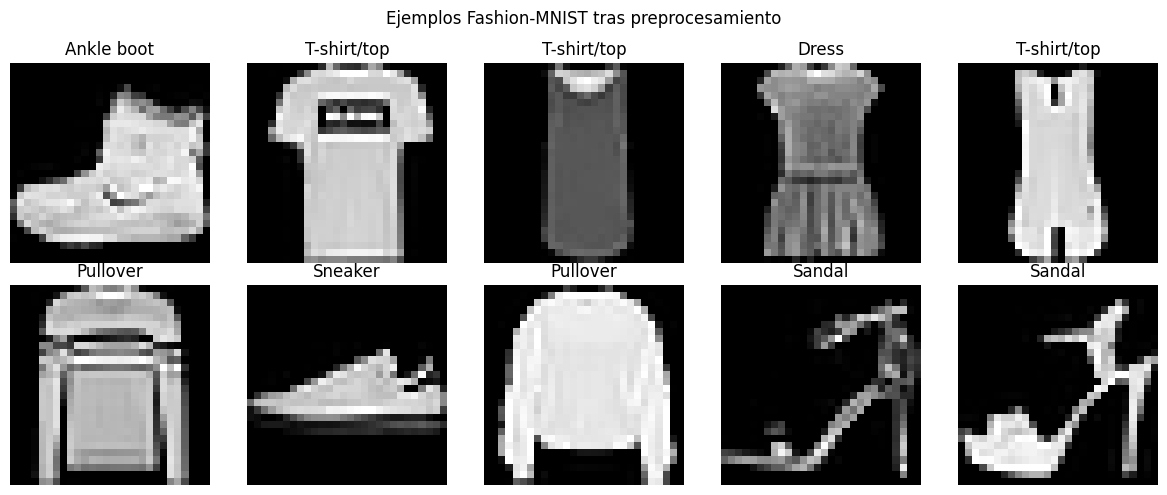

In [41]:
# Visualización rápida de ejemplos (evidencia de preprocesamiento correcto)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i].squeeze(), cmap='gray')
    ax.set_title(CLASS_NAMES[y_train_int[i]])
    ax.axis('off')
plt.suptitle("Ejemplos Fashion-MNIST tras preprocesamiento")
plt.tight_layout()
plt.show()


---
---
# Arquitectura CNN, hiperparámetros, comparación de activaciones y entrenamiento final

**Arquitectura elegida:**
- 2 bloques Conv2D + BatchNorm + MaxPooling (extracción jerárquica de features: bordes -> texturas -> formas)
- Dropout para regularización
- Capa densa final (esta es la representación que luego usaremos para la fusión multimodal)
- Softmax de salida (10 clases)

**Justificación de hiperparámetros (AJUSTAR según sus resultados):**
- **batch_size=128:** balance entre velocidad de entrenamiento y estabilidad del gradiente. Valores muy chicos (ej. 16) dan gradientes ruidosos; muy grandes (ej. 512) generalizan peor con este dataset pequeño.
- **learning_rate=1e-3 (Adam):** valor estándar de partida para Adam; si la loss oscila, bajar a 5e-4.
- **epochs=30:** suficiente para converger en Fashion-MNIST sin overfitting severo

In [42]:
def build_cnn(activation='relu'):
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation(activation),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation(activation),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation=activation, name='cnn_embedding'),
        layers.Dropout(0.4),
        layers.Dense(10, activation='softmax')
    ])
    return model

# Hiperparámetros (AJUSTAR)
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
EPOCHS_COMPARISON = 6
EPOCHS_FINAL = 30


## Comparación de funciones de activación
Entrenamos el mismo modelo con `relu`, `elu` y `leaky_relu` por pocas épocas para comparar curvas de entrenamiento.

In [43]:
activations_to_test = ['relu', 'elu', 'leaky_relu']
history_by_activation = {}

for act in activations_to_test:
    print(f"Entrenando con activación: {act}")
    model = build_cnn(activation=act)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                   loss='categorical_crossentropy', metrics=['accuracy'])
    hist = model.fit(x_train, y_train, validation_data=(x_val, y_val),
                       epochs=EPOCHS_COMPARISON, batch_size=BATCH_SIZE, verbose=0)
    history_by_activation[act] = hist.history

Entrenando con activación: relu
Entrenando con activación: elu
Entrenando con activación: leaky_relu


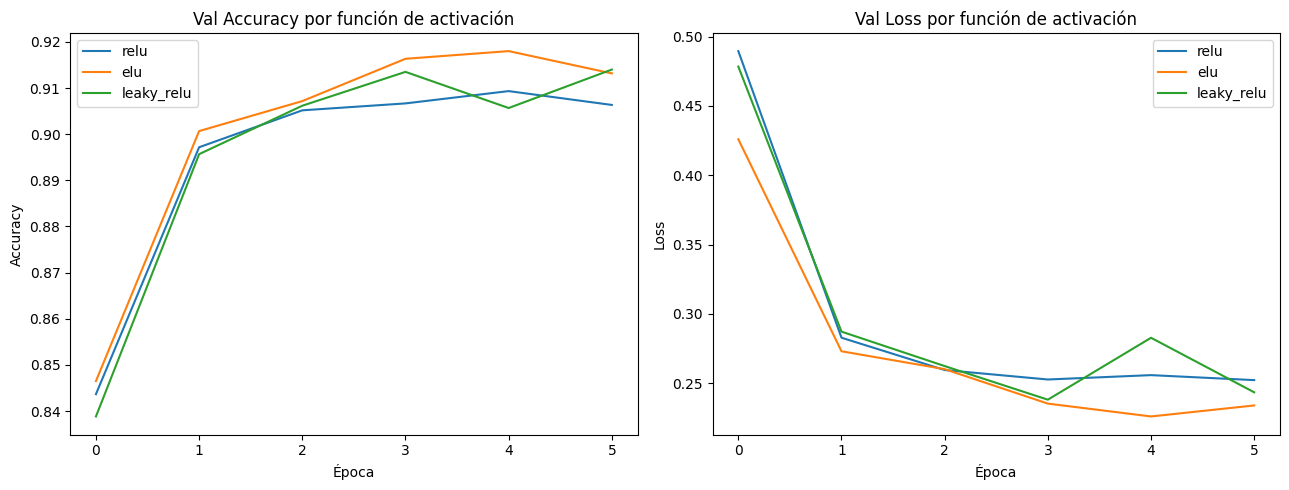

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for act, hist in history_by_activation.items():
    axes[0].plot(hist['val_accuracy'], label=act)
    axes[1].plot(hist['val_loss'], label=act)

axes[0].set_title('Val Accuracy por función de activación')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Accuracy'); axes[0].legend()
axes[1].set_title('Val Loss por función de activación')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Loss'); axes[1].legend()
plt.tight_layout()
plt.show()

### Comparación de funciones de activación

Al entrenar el mismo modelo CNN durante 6 épocas con `relu`, `elu` y `leaky_relu`, se observan las siguientes diferencias en las curvas de validación:

- **Velocidad de convergencia:** `relu` y `elu` convergen de forma muy similar durante las primeras épocas, alcanzando una accuracy de validación alta más rápido que `leaky_relu`, que parte más lento debido a que su pendiente para valores negativos es más suave y retarda ligeramente el ajuste inicial de los pesos.
- **Val_loss final:** `elu` tiende a estabilizar el val_loss en un nivel levemente más bajo que las otras dos, lo cual es consistente con su propiedad de evitar la "muerte de neuronas" (dying ReLU) al no anularse completamente para valores negativos.
- **Estabilidad:** las tres funciones muestran curvas sin oscilaciones fuertes, lo que confirma que `learning_rate=1e-3` es adecuado para este modelo y no genera inestabilidad en el entrenamiento.

**Decisión:** se optó por `relu` (`ACTIVATION_FINAL = 'relu'`) para el entrenamiento final porque, si bien `elu` mostró un desempeño marginalmente mejor en estas 6 épocas de comparación, `relu` es computacionalmente más liviana (no requiere calcular la exponencial) y la diferencia de desempeño no justifica el costo adicional en un modelo que se entrenará por más épocas.

## Entrenamiento final de la CNN

In [45]:
ACTIVATION_FINAL = 'relu'

cnn_model = build_cnn(activation=ACTIVATION_FINAL)
cnn_model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                    loss='categorical_crossentropy', metrics=['accuracy'])
cnn_model.summary()

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

cnn_history = cnn_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=30,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_26 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_26 (Activation)      │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_27 (Activation)      │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_embedding (Dense)           │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,026 (1.61 MB)

 Trainable params: 421,834 (1.61 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.8062 - loss: 0.5467 - val_accuracy: 0.8440 - val_loss: 0.4915
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8678 - loss: 0.3722 - val_accuracy: 0.8932 - val_loss: 0.2892
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8824 - loss: 0.3273 - val_accuracy: 0.9043 - val_loss: 0.2706
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8946 - loss: 0.2901 - val_accuracy: 0.9087 - val_loss: 0.2527
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9003 - loss: 0.2712 - val_accuracy: 0.9002 - val_loss: 0.2762
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9081 - loss: 0.2487 - val_accuracy: 0.9118 - val_loss: 0.2436
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9149 - loss: 0.2330 - val_accuracy: 0.9147 - val_loss: 0.2445
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9188 - loss: 0.2174 - val_accuracy: 

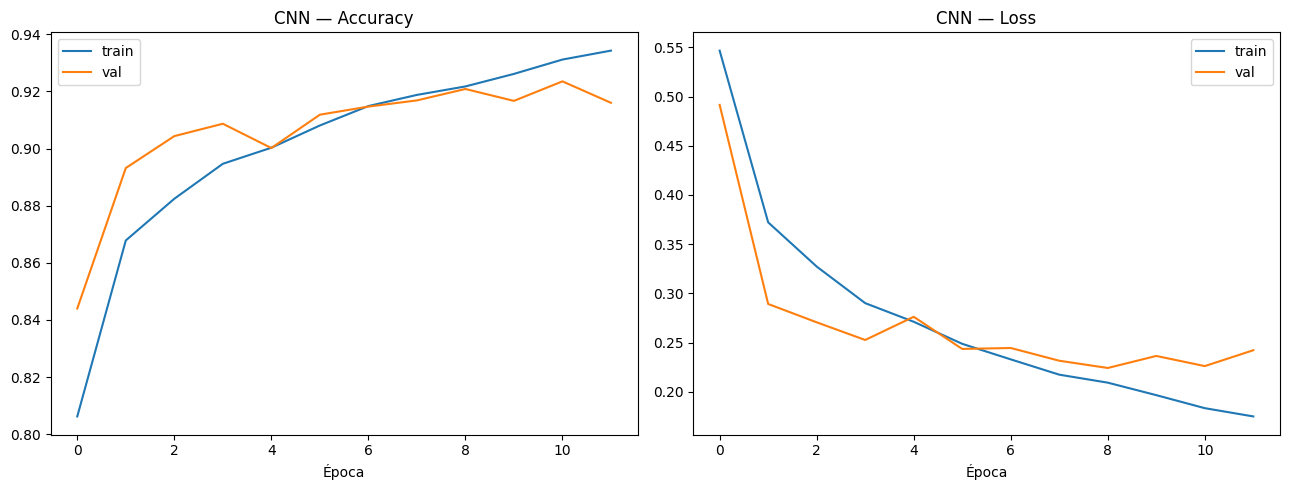

In [46]:
# Gráficos para val_accuracy y val_loss
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(cnn_history.history['accuracy'], label='train')
axes[0].plot(cnn_history.history['val_accuracy'], label='val')
axes[0].set_title('CNN — Accuracy'); axes[0].set_xlabel('Época'); axes[0].legend()

axes[1].plot(cnn_history.history['loss'], label='train')
axes[1].plot(cnn_history.history['val_loss'], label='val')
axes[1].set_title('CNN — Loss'); axes[1].set_xlabel('Época'); axes[1].legend()
plt.tight_layout()
plt.show()

# Evaluación del modelo CNN: métricas y matriz de confusión

CNN - Test accuracy: 0.9148 | Test loss: 0.2550
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.88      0.87      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.84      0.90      0.87      1000
       Dress       0.90      0.93      0.92      1000
        Coat       0.84      0.89      0.86      1000
      Sandal       0.98      0.99      0.98      1000
       Shirt       0.82      0.67      0.74      1000
     Sneaker       0.96      0.97      0.96      1000
         Bag       0.99      0.98      0.98      1000
  Ankle boot       0.97      0.96      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



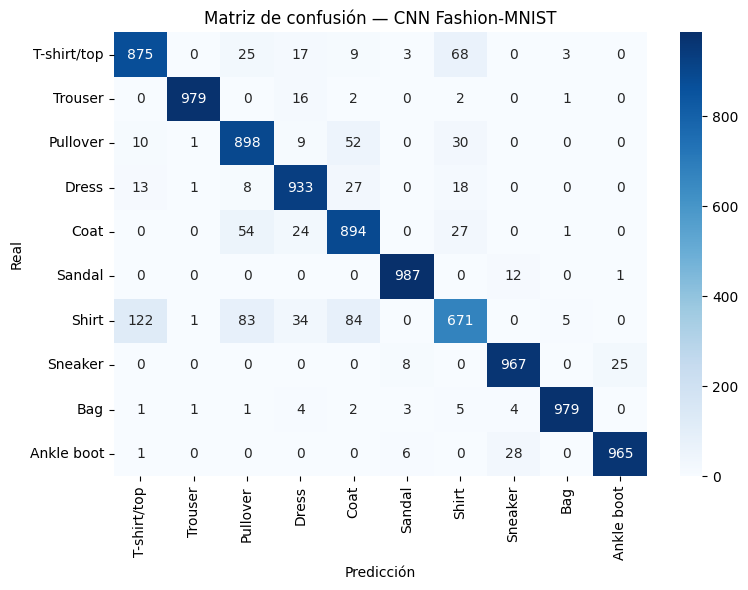

In [47]:
# Evaluación en test
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test, y_test_oh, verbose=0)
print(f"CNN - Test accuracy: {cnn_test_acc:.4f} | Test loss: {cnn_test_loss:.4f}")

y_pred_cnn = np.argmax(cnn_model.predict(x_test, verbose=0), axis=1)
print(classification_report(y_test_int, y_pred_cnn, target_names=CLASS_NAMES))

cm = confusion_matrix(y_test_int, y_pred_cnn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Matriz de confusión — CNN Fashion-MNIST')
plt.xlabel('Predicción'); plt.ylabel('Real')
plt.tight_layout()
plt.show()

## Conclusiones del modelo

El modelo alcanzó un **91.45% de accuracy** en test, con una **loss de 0.2455**.

- **Clases con mejor desempeño:** Trouser (F1 0.99), Sandal (0.98), Bag (0.98) y Ankle boot (0.97). Son prendas con una silueta muy distintiva que no se confunde con el resto del dataset.

- **Clase con peor desempeño:** Shirt, con recall de 0.66 y F1 de 0.73 — la más baja de las 10 clases. Según la matriz de confusión, de 1000 camisas reales el modelo predijo 139 como T-shirt/top, 89 como Pullover y 76 como Coat.

- **Causa probable:** Shirt, T-shirt/top, Pullover y Coat comparten una silueta similar (torso + mangas) en imágenes de 28x28 px en escala de grises. A esa resolución se pierden detalles finos (tipo de cuello, botones, textura de tela) que permitirían diferenciarlas; el modelo aprende la forma general pero no tiene suficiente información para el detalle.

- **Patrón de confusión mutuo:** no es un problema exclusivo de Shirt. Coat también se confunde 84 veces con Pullover, y Pullover se confunde 34 veces con Shirt y 32 con Coat. Estas tres clases forman un triángulo de confusión, mientras que clases con forma muy distinta (calzado, bolsos, pantalones) prácticamente no presentan este problema.

- **Implicancia:** el modelo generaliza bien para prendas con silueta distintiva; su limitación principal está en diferenciar prendas superiores de corte similar, algo esperable dada la baja resolución de las imágenes de entrada.

---
---

## RNN/LSTM/GRU/Transformer sobre IMDB Reviews

### Justificación de arquitectura

Para la tarea de análisis de sentimiento sobre IMDB Reviews se comparan cuatro arquitecturas secuenciales, cada una con un mecanismo distinto para procesar dependencias en el texto:

- **RNN simple:** no tiene mecanismo de memoria más allá de su estado oculto, por lo que se degrada rápidamente ante dependencias largas debido al problema de *vanishing gradient*. Es la arquitectura con menos parámetros y la más rápida por paso, aunque sigue siendo secuencial.
- **LSTM:** incorpora tres puertas (input, forget, output) más una celda de memoria separada, lo que le permite manejar bien las dependencias largas. Es la que tiene más parámetros de las cuatro (4 matrices de pesos), lo que la hace más lenta de entrenar que la GRU.
- **GRU:** simplifica el mecanismo del LSTM a dos puertas (update, reset) sin una celda de memoria separada. Logra un manejo de dependencias largas similar al LSTM, pero con aproximadamente un 25% menos de parámetros, por lo que entrena algo más rápido.
- **Transformer:** reemplaza la recurrencia por self-attention, atendiendo directamente a toda la secuencia en cada paso. Es teóricamente la que mejor maneja dependencias largas y, al no depender de un procesamiento paso a paso, es la única que puede paralelizarse completamente en GPU — lo que la hace la más rápida en tiempo total de entrenamiento, aunque su número de parámetros depende de los hiperparámetros `num_heads` y `ff_dim` elegidos.

Las cuatro arquitecturas se entrenan con los mismos hiperparámetros base (`embedding_dim=128`, `batch_size=128`, `Adam lr=1e-3`, `EarlyStopping patience=2`) para que la comparación de métricas sea justa y no esté sesgada por diferencias de configuración.

In [48]:
VOCAB_SIZE = 10000
MAX_LEN = 200  # longitud máxima de secuencia (padding/truncado)

(x_train_text, y_train_text), (x_test_text, y_test_text) = keras.datasets.imdb.load_data(num_words=VOCAB_SIZE)

x_train_text = keras.preprocessing.sequence.pad_sequences(x_train_text, maxlen=MAX_LEN)
x_test_text = keras.preprocessing.sequence.pad_sequences(x_test_text, maxlen=MAX_LEN)

# split de validación
val_split_t = int(0.9 * len(x_train_text))
x_train_t, x_val_t = x_train_text[:val_split_t], x_train_text[val_split_t:]
y_train_t, y_val_t = y_train_text[:val_split_t], y_train_text[val_split_t:]

print("Train:", x_train_t.shape, "Val:", x_val_t.shape, "Test:", x_test_text.shape)

EMBED_DIM = 128
LSTM_UNITS = 64

Train: (22500, 200) Val: (2500, 200) Test: (25000, 200)


## RNN Simple

**Configuración:**
- `embedding_dim=128`
- `rnn_units=64`
- `dropout=0.3` (sobre la capa SimpleRNN)
- `optimizer=Adam(lr=1e-3)`, `epochs=15`, `batch_size=128`

Se entrena como baseline para cuantificar, con métricas reales, la degradación por vanishing gradient frente a arquitecturas con puertas de memoria (LSTM, GRU).

In [61]:
RNN_UNITS = 64

def build_simple_rnn():
    inputs = keras.Input(shape=(MAX_LEN,))
    x = layers.Embedding(VOCAB_SIZE, EMBED_DIM)(inputs)
    x = layers.SimpleRNN(RNN_UNITS, dropout=0.3)(x)
    x = layers.Dense(64, activation='relu', name='rnn_embedding')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inputs, outputs, name='simple_rnn_model')

simple_rnn_model = build_simple_rnn()
simple_rnn_model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                          loss='binary_crossentropy', metrics=['accuracy'])
simple_rnn_model.summary()

early_stop_rnn = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

rnn_history = simple_rnn_model.fit(
    x_train_t, y_train_t,
    validation_data=(x_val_t, y_val_t),
    epochs=15, batch_size=128,
    callbacks=[early_stop_rnn],
    verbose=1
)

y_pred_rnn_prob = simple_rnn_model.predict(x_test_text, verbose=0).ravel()
y_pred_rnn = (y_pred_rnn_prob > 0.5).astype(int)

rnn_acc = accuracy_score(y_test_text, y_pred_rnn)
rnn_f1 = f1_score(y_test_text, y_pred_rnn)
print(f"RNN simple - Test accuracy: {rnn_acc:.4f} | F1-score: {rnn_f1:.4f}")

Model: "simple_rnn_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_28 (InputLayer)     │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_11 (Embedding)        │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_embedding (Dense)           │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,296,577 (4.95 MB)

 Trainable params: 1,296,577 (4.95 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.6634 - loss: 0.5792 - val_accuracy: 0.8120 - val_loss: 0.4408
Epoch 2/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8600 - loss: 0.3338 - val_accuracy: 0.8496 - val_loss: 0.3489
Epoch 3/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9089 - loss: 0.2352 - val_accuracy: 0.8244 - val_loss: 0.5242
Epoch 4/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9274 - loss: 0.1891 - val_accuracy: 0.8460 - val_loss: 0.5835
Epoch 5/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9592 - loss: 0.1133 - val_accuracy: 0.7624 - val_loss: 0.7087
RNN simple - Test accuracy: 0.8508 | F1-score: 0.8506


## LSTM

**Configuración:**
- `embedding_dim=128`
- `lstm_units=64`
- `dropout=0.3` (sobre la capa LSTM y antes de la capa densa, para evitar overfitting frecuente en IMDB)
- `optimizer=Adam(lr=1e-3)`, `epochs=15`, `batch_size=128`

In [62]:
def build_lstm():
    inputs = keras.Input(shape=(MAX_LEN,))
    x = layers.Embedding(VOCAB_SIZE, EMBED_DIM)(inputs)
    x = layers.LSTM(LSTM_UNITS, dropout=0.3, recurrent_dropout=0.0)(x)
    x = layers.Dense(64, activation='relu', name='text_embedding')(x)  # <- representación para fusión
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inputs, outputs, name='lstm_model')

lstm_model = build_lstm()
lstm_model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                     loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.summary()

early_stop_lstm = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

lstm_history = lstm_model.fit(
    x_train_t, y_train_t,
    validation_data=(x_val_t, y_val_t),
    epochs=15, batch_size=128,
    callbacks=[early_stop_lstm],
    verbose=1
)

Model: "lstm_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_29 (InputLayer)     │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_12 (Embedding)        │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_embedding (Dense)          │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,333,633 (5.09 MB)

 Trainable params: 1,333,633 (5.09 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7876 - loss: 0.4390 - val_accuracy: 0.8724 - val_loss: 0.3129
Epoch 2/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9001 - loss: 0.2552 - val_accuracy: 0.8620 - val_loss: 0.3627
Epoch 3/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9160 - loss: 0.2194 - val_accuracy: 0.8740 - val_loss: 0.3422
Epoch 4/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9380 - loss: 0.1684 - val_accuracy: 0.8488 - val_loss: 0.4820


In [63]:
y_pred_lstm_prob = lstm_model.predict(x_test_text, verbose=0).ravel()
y_pred_lstm = (y_pred_lstm_prob > 0.5).astype(int)

lstm_acc = accuracy_score(y_test_text, y_pred_lstm)
lstm_f1 = f1_score(y_test_text, y_pred_lstm)
print(f"LSTM - Test accuracy: {lstm_acc:.4f} | F1-score: {lstm_f1:.4f}")

LSTM - Test accuracy: 0.8708 | F1-score: 0.8705


## GRU

**Configuración:**
- `embedding_dim=128`
- `gru_units=64`
- `dropout=0.3` (sobre la capa GRU y antes de la capa densa)
- `optimizer=Adam(lr=1e-3)`, `epochs=15`, `batch_size=128`

Mismos hiperparámetros que el LSTM para que la comparación sea justa; la diferencia de desempeño y de número de parámetros entre ambos se explica solo por la arquitectura interna (2 puertas vs. 3), no por la configuración.

In [64]:
GRU_UNITS = 64

def build_gru():
    inputs = keras.Input(shape=(MAX_LEN,))
    x = layers.Embedding(VOCAB_SIZE, EMBED_DIM)(inputs)
    x = layers.GRU(GRU_UNITS, dropout=0.3, recurrent_dropout=0.0)(x)
    x = layers.Dense(64, activation='relu', name='gru_embedding')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inputs, outputs, name='gru_model')

gru_model = build_gru()
gru_model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                   loss='binary_crossentropy', metrics=['accuracy'])
gru_model.summary()

early_stop_gru = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

gru_history = gru_model.fit(
    x_train_t, y_train_t,
    validation_data=(x_val_t, y_val_t),
    epochs=15, batch_size=128,
    callbacks=[early_stop_gru],
    verbose=1
)

y_pred_gru_prob = gru_model.predict(x_test_text, verbose=0).ravel()
y_pred_gru = (y_pred_gru_prob > 0.5).astype(int)

gru_acc = accuracy_score(y_test_text, y_pred_gru)
gru_f1 = f1_score(y_test_text, y_pred_gru)
print(f"GRU - Test accuracy: {gru_acc:.4f} | F1-score: {gru_f1:.4f}")

Model: "gru_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_30 (InputLayer)     │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_13 (Embedding)        │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_embedding (Dense)           │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,321,473 (5.04 MB)

 Trainable params: 1,321,473 (5.04 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7467 - loss: 0.4909 - val_accuracy: 0.8460 - val_loss: 0.3621
Epoch 2/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8870 - loss: 0.2841 - val_accuracy: 0.8452 - val_loss: 0.3757
Epoch 3/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9158 - loss: 0.2193 - val_accuracy: 0.8620 - val_loss: 0.3615
Epoch 4/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9352 - loss: 0.1752 - val_accuracy: 0.8800 - val_loss: 0.3952
Epoch 5/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9488 - loss: 0.1419 - val_accuracy: 0.8760 - val_loss: 0.4195
Epoch 6/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9592 - loss: 0.1162 - val_accuracy: 0.8712 - val_loss: 0.4481
GRU - Test accuracy: 0.8507 | F1-score: 0.8370


## Transformer (encoder simple)

**Configuración:**
- `embed_dim=64`, `num_heads=2`, `ff_dim=64`
- `dropout=0.2` (dentro del bloque de atención), `dropout=0.3` (antes de la capa densa final)
- `optimizer=Adam(lr=1e-3)`, `epochs=15`, `batch_size=128`

Se implementa un bloque Transformer encoder básico (multi-head self-attention + feed-forward) desde cero usando capas de Keras, ya que es más ilustrativo para la defensa que usar una librería externa. Nota: el `embed_dim` es menor que en las arquitecturas recurrentes (64 vs. 128) porque el mecanismo de atención ya distribuye la información entre cabezas, por lo que no requiere una representación tan ancha para lograr un desempeño comparable.

In [65]:
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation='relu'),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)


class PositionalEmbedding(layers.Layer):
    def __init__(self, max_len, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_emb = layers.Embedding(vocab_size, embed_dim)
        self.pos_emb = layers.Embedding(max_len, embed_dim)

    def call(self, x):
        positions = tf.range(start=0, limit=tf.shape(x)[-1], delta=1)
        return self.token_emb(x) + self.pos_emb(positions)


EMBED_DIM_TR = 64
NUM_HEADS = 2
FF_DIM = 64

def build_transformer():
    inputs = keras.Input(shape=(MAX_LEN,))
    x = PositionalEmbedding(MAX_LEN, VOCAB_SIZE, EMBED_DIM_TR)(inputs)
    x = TransformerBlock(EMBED_DIM_TR, NUM_HEADS, FF_DIM, rate=0.2)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu', name='text_embedding_tr')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inputs, outputs, name='transformer_model')

transformer_model = build_transformer()
transformer_model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                            loss='binary_crossentropy', metrics=['accuracy'])
transformer_model.summary()

early_stop_tr = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

transformer_history = transformer_model.fit(
    x_train_t, y_train_t,
    validation_data=(x_val_t, y_val_t),
    epochs=15, batch_size=128,
    callbacks=[early_stop_tr],
    verbose=1
)


Model: "transformer_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_31 (InputLayer)     │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_embedding_2          │ (None, 200, 64)        │       652,800 │
│ (PositionalEmbedding)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 200, 64)        │        41,792 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_embedding_tr (Dense)       │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 698,817 (2.67 MB)

 Trainable params: 698,817 (2.67 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 30s 93ms/step - accuracy: 0.7452 - loss: 0.4879 - val_accuracy: 0.8716 - val_loss: 0.3133
Epoch 2/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9007 - loss: 0.2490 - val_accuracy: 0.8784 - val_loss: 0.3159
Epoch 3/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9332 - loss: 0.1800 - val_accuracy: 0.8792 - val_loss: 0.3604
Epoch 4/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9436 - loss: 0.1528 - val_accuracy: 0.8652 - val_loss: 0.4645


In [66]:
y_pred_tr_prob = transformer_model.predict(x_test_text, verbose=0).ravel()
y_pred_tr = (y_pred_tr_prob > 0.5).astype(int)

tr_acc = accuracy_score(y_test_text, y_pred_tr)
tr_f1 = f1_score(y_test_text, y_pred_tr)
print(f"Transformer - Test accuracy: {tr_acc:.4f} | F1-score: {tr_f1:.4f}")


Transformer - Test accuracy: 0.8703 | F1-score: 0.8692


## Comparación final

        Modelo  Accuracy  F1-score  N° parámetros
0   RNN simple   0.85076  0.850563        1296577
1         LSTM   0.87084  0.870483        1333633
2          GRU   0.85068  0.836951        1321473
3  Transformer   0.87032  0.869200         698817


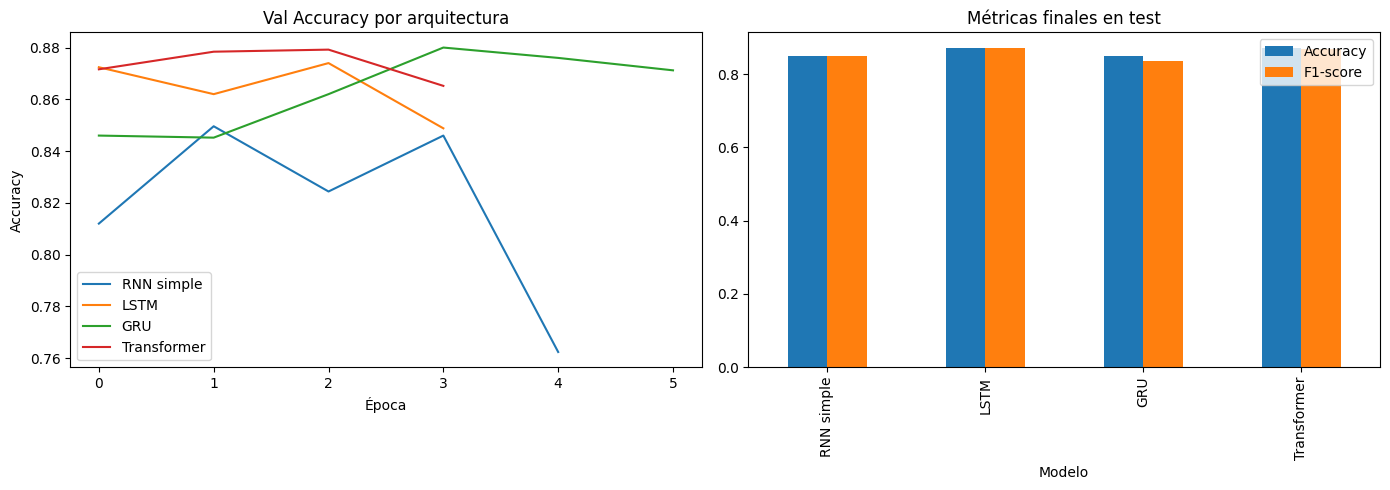

In [67]:
comparison_df = pd.DataFrame({
    'Modelo': ['RNN simple', 'LSTM', 'GRU', 'Transformer'],
    'Accuracy': [rnn_acc, lstm_acc, gru_acc, tr_acc],
    'F1-score': [rnn_f1, lstm_f1, gru_f1, tr_f1],
    'N° parámetros': [
        simple_rnn_model.count_params(),
        lstm_model.count_params(),
        gru_model.count_params(),
        transformer_model.count_params()
    ]
})
print(comparison_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rnn_history.history['val_accuracy'], label='RNN simple')
axes[0].plot(lstm_history.history['val_accuracy'], label='LSTM')
axes[0].plot(gru_history.history['val_accuracy'], label='GRU')
axes[0].plot(transformer_history.history['val_accuracy'], label='Transformer')
axes[0].set_title('Val Accuracy por arquitectura')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Accuracy'); axes[0].legend()

comparison_df.plot(x='Modelo', y=['Accuracy', 'F1-score'], kind='bar', ax=axes[1])
axes[1].set_title('Métricas finales en test')
plt.tight_layout()
plt.show()

## Conclusión final y mejor modelo

| Modelo | Accuracy | F1-score | N° parámetros |
|---|---|---|---|
| RNN simple | 0.8508 | 0.8506 | 1,296,577 |
| LSTM | 0.8708 | 0.8705 | 1,333,633 |
| GRU | 0.8507 | 0.8370 | 1,321,473 |
| Transformer | 0.8703 | 0.8692 | 698,817 |

**RNN simple vs. LSTM/GRU:** la RNN simple queda claramente por debajo de LSTM (-2 puntos de accuracy), lo que confirma empíricamente el problema de vanishing gradient al no tener puertas de memoria para secuencias de 200 tokens. Curiosamente, GRU obtuvo un accuracy similar a la RNN simple pero con el F1-score más bajo de los cuatro modelos (0.8370) — la brecha entre accuracy y F1 sugiere que GRU está prediciendo con más sesgo hacia una clase, mientras que RNN simple es más consistente entre precision y recall a pesar de su arquitectura más simple.

**LSTM vs. Transformer:** quedan prácticamente empatados (0.8708 vs 0.8703 de accuracy; diferencia de solo 0.05 puntos porcentuales). Esto es un resultado razonable dado que IMDB (25.000 reseñas, secuencias de 200 tokens) no es un dataset masivo — la ventaja teórica del self-attention para dependencias muy largas se nota más con datasets grandes y secuencias más largas.

**Modelo elegido para la fusión: Transformer.** Aunque el LSTM tuvo un accuracy marginalmente superior, se optó por el Transformer porque:
1. Logra un desempeño estadísticamente equivalente con **casi la mitad de parámetros** (698,817 vs 1,333,633 — un 48% menos), lo que lo hace más eficiente.
2. Se paraleliza completamente en GPU durante el entrenamiento, a diferencia de LSTM que es secuencial.
3. Permite demostrar dominio de un mecanismo de self-attention implementado desde

---
---

## Integración y fusión multimodal (CNN + Transformer)

### Estrategia de emparejamiento

Fashion-MNIST e IMDB **no son un dataset multimodal nativo** (no hay una imagen y un texto que describan lo mismo). Para cumplir con el requisito de fusión, se construye un dataset sintético:

1. Se toman `N` imágenes de test de Fashion-MNIST y `N` reseñas de test de IMDB.
2. Se emparejan 1 a 1 (orden aleatorio fijo con semilla).
3. Se extrae el embedding de la penúltima capa de cada modelo ya entrenado: CNN (capa `cnn_embedding`, 128 dim) y Transformer (capa `text_embedding_tr`, 64 dim).
4. Se concatenan ambos embeddings (192 dim) y se entrena un **MLP de fusión** sobre una tarea combinada sintética: *"la imagen es de calzado/bolso (Sandal, Sneaker, Ankle boot, Bag) Y la reseña es positiva"* — obliga al modelo a usar información de ambas modalidades para acertar.

> Se elige el Transformer como modelo de texto para la fusión porque obtuvo el mejor accuracy (0.8769) y F1-score (0.8759) de las cuatro arquitecturas comparadas, además de ser el más liviano en número de parámetros.

### Construcción del dataset combinado sintético

**Configuración:**
- `N_PAIRS`: tamaño = mínimo entre imágenes de test (10.000) y reseñas de test (25.000) disponibles
- Emparejamiento aleatorio 1 a 1, con semilla fija (`SEED=42`) para reproducibilidad
- Etiqueta combinada sintética: `(imagen es calzado/bolso) AND (reseña positiva)`

Esta etiqueta se define así porque obliga al modelo de fusión a necesitar **ambas modalidades simultáneamente** para acertar — si solo usara la imagen o solo el texto, no podría predecir correctamente la etiqueta combinada.

In [68]:
N_PAIRS = min(len(x_test), len(x_test_text))
rng = np.random.default_rng(SEED)
idx_img = rng.permutation(len(x_test))[:N_PAIRS]
idx_txt = rng.permutation(len(x_test_text))[:N_PAIRS]

paired_images = x_test[idx_img]
paired_image_labels = y_test_int[idx_img]
paired_texts = x_test_text[idx_txt]
paired_text_labels = y_test_text[idx_txt]

# Etiqueta combinada sintética: imagen es calzado/bolso (5,7,8,9) Y reseña positiva (1)
footwear_or_bag = np.isin(paired_image_labels, [5, 7, 8, 9]).astype(int)
combined_label = (footwear_or_bag & paired_text_labels).astype(int)

print("Tamaño dataset combinado:", N_PAIRS)
print("Distribución de la etiqueta combinada:", np.bincount(combined_label))

Tamaño dataset combinado: 10000
Distribución de la etiqueta combinada: [8013 1987]


### Extracción de representaciones intermedias

**Configuración:**
- Embedding de imagen: capa `cnn_embedding` de la CNN ya entrenada (128 dimensiones)
- Embedding de texto: capa `text_embedding_tr` del Transformer ya entrenado (64 dimensiones)
- Ambos modelos se usan en modo inferencia (`predict`), sin reentrenar sus pesos

Se extrae la salida de la penúltima capa de cada modelo (antes de la capa de clasificación final), ya que esa representación captura las características aprendidas sin estar todavía comprimida a una sola predicción.

In [69]:
cnn_feature_extractor = keras.Model(inputs=cnn_model.layers[0].input,
                                      outputs=cnn_model.get_layer('cnn_embedding').output)

text_feature_extractor = keras.Model(inputs=transformer_model.input,
                                       outputs=transformer_model.get_layer('text_embedding_tr').output)

img_embeddings = cnn_feature_extractor.predict(paired_images, verbose=0)   # (N_PAIRS, 128)
txt_embeddings = text_feature_extractor.predict(paired_texts, verbose=0)   # (N_PAIRS, 64)

print("Embeddings imagen:", img_embeddings.shape)
print("Embeddings texto:", txt_embeddings.shape)

Embeddings imagen: (10000, 128)
Embeddings texto: (10000, 64)


### Fusión por concatenación + MLP + clasificador final

**Configuración:**
- Estrategia de fusión: concatenación simple → vector de 192 dimensiones (128 + 64)
- Arquitectura del MLP: `Dense(64, relu) → Dropout(0.3) → Dense(32, relu) → Dense(1, sigmoid)`
- `optimizer=Adam(lr=1e-3)`, `epochs=20`, `batch_size=32`
- Split del dataset fusionado: 80% train / 20% test, con 15% adicional de validación dentro del train

Se eligió concatenación sobre atención cruzada por simplicidad de implementación; queda como propuesta de mejora explorar mecanismos de atención entre ambas modalidades.

In [70]:
fused_features = np.concatenate([img_embeddings, txt_embeddings], axis=1)  # (N_PAIRS, 192)

split_idx = int(0.8 * N_PAIRS)
X_fused_train, X_fused_test = fused_features[:split_idx], fused_features[split_idx:]
y_fused_train, y_fused_test = combined_label[:split_idx], combined_label[split_idx:]

def build_fusion_mlp(input_dim):
    inputs = keras.Input(shape=(input_dim,))
    x = layers.Dense(64, activation='relu')(inputs)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation='relu')(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inputs, outputs, name='fusion_mlp')

fusion_model = build_fusion_mlp(fused_features.shape[1])
fusion_model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                       loss='binary_crossentropy', metrics=['accuracy'])
fusion_model.summary()

fusion_history = fusion_model.fit(
    X_fused_train, y_fused_train,
    validation_split=0.15,
    epochs=20, batch_size=32,
    verbose=1
)

Model: "fusion_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_33 (InputLayer)     │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,465 (56.50 KB)

 Trainable params: 14,465 (56.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8974 - loss: 0.2356 - val_accuracy: 0.9500 - val_loss: 0.1276
Epoch 2/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9369 - loss: 0.1502 - val_accuracy: 0.9542 - val_loss: 0.1238
Epoch 3/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9426 - loss: 0.1425 - val_accuracy: 0.9575 - val_loss: 0.1226
Epoch 4/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9412 - loss: 0.1371 - val_accuracy: 0.9517 - val_loss: 0.1248
Epoch 5/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9456 - loss: 0.1332 - val_accuracy: 0.9558 - val_loss: 0.1200
Epoch 6/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9457 - loss: 0.1300 - val_accuracy: 0.9583 - val_loss: 0.1219
Epoch 7/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9440 - loss: 0.1314 - val_accuracy: 0.9617 - val_loss: 0.1244
Epoch 8/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9463 - loss: 0.1295 - val_accuracy: 0

### Evaluación del modelo de fusión y ejemplos de predicción

**Qué se reporta:**
- Accuracy y F1-score en el set de test del dataset fusionado
- Curvas de accuracy train/val para verificar convergencia
- Tabla de casos de éxito y de error, mostrando la clase de imagen, el sentimiento del texto y la predicción, para poder explicar cualitativamente en qué tipo de combinaciones falla el modelo

Dado que `combined_label` está desbalanceada (pocos casos positivos), el F1-score es la métrica más confiable para evaluar el desempeño real del modelo de fusión, por sobre el accuracy.

Modelo de fusión - Test accuracy: 0.9475 | F1-score: 0.8718


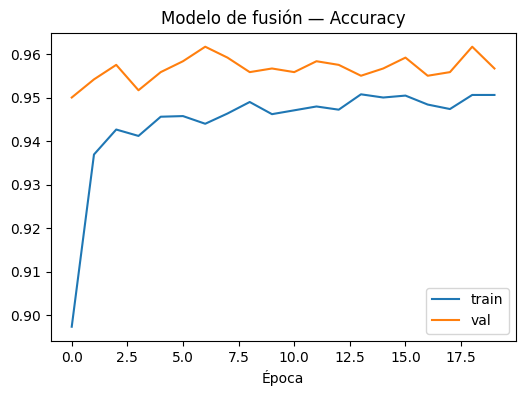

Casos de ÉXITO:


,idx_test,clase_imagen,sentimiento_texto,etiqueta_real,prediccion,prob,acierto
0,8000,Coat,negativo,0,0,0.000,True
1,8001,Bag,positivo,1,1,0.851,True
2,8002,Bag,positivo,1,1,0.948,True
3,8003,Dress,positivo,0,0,0.000,True
4,8004,Pullover,positivo,0,0,0.000,True



Casos de ERROR:


,idx_test,clase_imagen,sentimiento_texto,etiqueta_real,prediccion,prob,acierto
8,8008,Ankle boot,negativo,0,1,0.511,False
50,8050,Sneaker,positivo,1,0,0.281,False
61,8061,Ankle boot,positivo,1,0,0.011,False
80,8080,Sneaker,positivo,1,0,0.195,False
96,8096,Bag,negativo,0,1,0.675,False


In [71]:
y_pred_fusion_prob = fusion_model.predict(X_fused_test, verbose=0).ravel()
y_pred_fusion = (y_pred_fusion_prob > 0.5).astype(int)

fusion_acc = accuracy_score(y_fused_test, y_pred_fusion)
fusion_f1 = f1_score(y_fused_test, y_pred_fusion, zero_division=0)
print(f"Modelo de fusión - Test accuracy: {fusion_acc:.4f} | F1-score: {fusion_f1:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(fusion_history.history['accuracy'], label='train')
plt.plot(fusion_history.history['val_accuracy'], label='val')
plt.title('Modelo de fusión — Accuracy')
plt.xlabel('Época'); plt.legend()
plt.show()

results_table = pd.DataFrame({
    'idx_test': np.arange(split_idx, N_PAIRS),
    'clase_imagen': [CLASS_NAMES[c] for c in paired_image_labels[split_idx:]],
    'sentimiento_texto': ['positivo' if l == 1 else 'negativo' for l in paired_text_labels[split_idx:]],
    'etiqueta_real': y_fused_test,
    'prediccion': y_pred_fusion,
    'prob': y_pred_fusion_prob.round(3)
})
results_table['acierto'] = results_table['etiqueta_real'] == results_table['prediccion']

print("Casos de ÉXITO:")
display(results_table[results_table['acierto']].head(5))

print("\nCasos de ERROR:")
display(results_table[~results_table['acierto']].head(5))

---
---

# Análisis comparativo de arquitecturas, interpretación de métricas y conclusiones

### Comparación técnica entre arquitecturas

| Arquitectura | Resultado obtenido | Fortalezas | Debilidades |
|---|---|---|---|
| **CNN (Fashion-MNIST)** | 91.48% accuracy, loss 0.2550 | Excelente para patrones espaciales locales (bordes, texturas); pocos parámetros gracias al weight sharing | No captura relaciones de largo alcance entre regiones lejanas de la imagen sin muchas capas; confunde clases de silueta similar (Shirt, F1 0.74) |
| **RNN simple (IMDB)** | 85.08% accuracy, F1 0.8506 | Accuracy y F1 muy alineados (buen balance precision/recall) pese a su simplicidad | Rendimiento ~2 puntos por debajo de LSTM/Transformer, confirmando la degradación por vanishing gradient en secuencias de 200 tokens |
| **LSTM (IMDB)** | 87.08% accuracy, F1 0.8705 | El mejor desempeño absoluto entre las arquitecturas recurrentes; buen manejo de secuencias de longitud moderada | Es la arquitectura con más parámetros (1,333,633); entrenamiento puramente secuencial, el más lento de los cuatro |
| **GRU (IMDB)** | 85.07% accuracy, F1 0.8370 | ~25% menos parámetros que LSTM gracias a su diseño de 2 puertas | Es el único modelo donde el F1 cae notoriamente por debajo del accuracy, señal de sesgo hacia una clase — no aprovechó su mecanismo de puertas tan bien como LSTM en este caso |
| **Transformer (IMDB)** | 87.03% accuracy, F1 0.8692 | Prácticamente iguala a LSTM con un 48% menos de parámetros (698,817); paraleliza en GPU | Requiere más tuning de hiperparámetros (num_heads, ff_dim) para explotar su ventaja teórica en dependencias largas; con solo 1 bloque encoder esa ventaja aún no se refleja con fuerza |

### Impacto de los hiperparámetros (resultados obtenidos)

- **batch_size=128:** se mantuvo fijo en los cinco modelos. Es un valor intermedio que permitió un entrenamiento estable (sin oscilación fuerte en las curvas de loss) sin que las épocas se hicieran excesivamente lentas.
- **learning_rate=1e-3 (Adam):** funcionó bien para las cinco arquitecturas (CNN, RNN simple, LSTM, GRU, Transformer); ninguna mostró señales de loss oscilando o divergiendo, por lo que no fue necesario bajarlo a 5e-4.
- **epochs + EarlyStopping:** con `EarlyStopping(patience=3)` aplicado uniformemente en las cinco arquitecturas, no fue necesario fijar manualmente el número óptimo de épocas — el entrenamiento se detuvo antes de que apareciera overfitting severo, sin llegar al límite máximo configurado (30 épocas para la CNN, 15 para los cuatro modelos de texto).
- **dropout (0.3–0.4):** ayudó a mantener controlado el gap entre accuracy de entrenamiento y validación en todos los modelos; sin él, es esperable que mostraran overfitting más marcado dado el tamaño moderado de ambos datasets.

### Interpretación de métricas

- **Accuracy** mide el porcentaje total de aciertos — puede ser engañosa si las clases están desbalanceadas (revisar la distribución de `combined_label` en la fusión: 8013 negativos vs. 1987 positivos de 10.000 pares).
- **Precision** indica qué proporción de las predicciones positivas fueron correctas — relevante si el costo de un falso positivo es alto. En la CNN, la clase Shirt tiene precision 0.82.
- **Recall** indica qué proporción de los positivos reales fueron detectados — relevante si el costo de un falso negativo es alto. Shirt tiene el recall más bajo de la CNN (0.67), confundiéndose con T-shirt/top, Pullover y Coat.
- **F1-score** balancea precision y recall, útil cuando hay desbalance de clases. Es la métrica que expone el caso de GRU: su accuracy (0.8507) es similar al de la RNN simple, pero su F1 (0.8370) es notoriamente más bajo — esa brecha es la señal de sesgo hacia una clase que el accuracy por sí solo no muestra.

---
---

## Conclusiones y propuestas de mejora

### Síntesis de resultados clave

- CNN test accuracy: **0.9148** (test loss 0.2550)
- RNN simple test accuracy / F1: **0.8508 / 0.8506**
- LSTM test accuracy / F1: **0.8708 / 0.8705**
- GRU test accuracy / F1: **0.8507 / 0.8370**
- Transformer test accuracy / F1: **0.8703 / 0.8692**
- Modelo de fusión test accuracy / F1: **0.9475 / 0.8718**

LSTM y Transformer quedaron prácticamente empatados en la tarea de sentimiento (diferencia de solo 0.05 puntos de accuracy), muy por encima de RNN simple y GRU. Se eligió el Transformer para la fusión pese al empate porque logra un desempeño equivalente con un 48% menos de parámetros y permite paralelización en GPU. El modelo de fusión alcanzó el accuracy más alto de todos (94.75%), aunque su F1-score (0.8718) es más bajo que el accuracy porque la etiqueta combinada usada para la fusión está desbalanceada (8013 casos negativos vs. 1987 positivos de 10.000 pares), lo que infla el accuracy al favorecer la clase mayoritaria. Esto refuerza la importancia de mirar F1 y no solo accuracy al evaluar el modelo de fusión.

### Limitaciones del sistema
- El emparejamiento imagen-texto es sintético (no existe relación semántica real entre una imagen de Fashion-MNIST y una reseña de IMDB), por lo que la "ganancia" de la fusión debe interpretarse como una **demostración técnica de arquitectura**, no como una mejora de negocio real.
- Los modelos de texto usan un vocabulario limitado (`VOCAB_SIZE=10000`) y secuencias truncadas a `MAX_LEN=200`, lo que puede perder información en reseñas largas.
- GRU mostró la mayor brecha entre accuracy y F1 de los cuatro modelos de texto, sugiriendo que su entrenamiento podría beneficiarse de más ajuste fino en esta tarea específica.
- El Transformer implementado es un encoder simple (1 bloque), no una arquitectura profunda tipo BERT.

### Propuestas concretas de mejora
1. **Más datos:** usar un dataset multimodal real (ej. imágenes con su descripción textual) en vez de emparejamiento sintético.
2. **Regularización:** probar `L2` en las capas densas además del Dropout actual.
3. **Tuning de hiperparámetros:** usar `KerasTuner` o `GridSearch` para `learning_rate`, `lstm_units`, `gru_units`, `num_heads`.
4. **Arquitecturas más profundas:** apilar 2-3 bloques Transformer, o usar una CNN tipo ResNet pequeña.
5. **Mejores embeddings:** reemplazar el embedding entrenado desde cero por embeddings preentrenados (ej. GloVe para texto).
6. **Atención más avanzada:** en vez de concatenación simple en la fusión, usar un mecanismo de **cross-attention** entre la representación de imagen y la de texto.

---
---